# Pandas tutorial

In [127]:
import pandas as pd

data = {
    "Name": [
        "Anna", "John", "Sara", "Mike", "Lina",
        "David", "Emma", "Noah", "Olivia", "Lucas"
    ],
    "Age": [
        25, 30, 22, 35, 28,
        40, 27, 31, 24, 29
    ],
    "Department": [
        "HR", "IT", "Finance", "IT", "Marketing",
        "Finance", "HR", "IT", "Marketing", "Finance"
    ],
    "Salary": [
        4000, 5500, 4200, 6000, 4500,
        6500, 4100, 5800, 4700, 6200
    ]
}

df = pd.DataFrame(data)
print(df)

     Name  Age Department  Salary
0    Anna   25         HR    4000
1    John   30         IT    5500
2    Sara   22    Finance    4200
3    Mike   35         IT    6000
4    Lina   28  Marketing    4500
5   David   40    Finance    6500
6    Emma   27         HR    4100
7    Noah   31         IT    5800
8  Olivia   24  Marketing    4700
9   Lucas   29    Finance    6200


In [128]:
# data inspection
df.head()        # preview rows

,Name,Age,Department,Salary
0,Anna,25,HR,4000
1,John,30,IT,5500
2,Sara,22,Finance,4200
3,Mike,35,IT,6000
4,Lina,28,Marketing,4500


In [129]:
df.describe()    # statistical summary

,Age,Salary
count,10.0000,10.00000
mean,29.1000,5150.00000
std,5.3427,951.31488
min,22.0000,4000.00000
25%,25.5000,4275.00000
50%,28.5000,5100.00000
75%,30.7500,5950.00000
max,40.0000,6500.00000


In [130]:
df.columns       # column names

Index(['Name', 'Age', 'Department', 'Salary'], dtype='object')

In [131]:
df.info() # data types 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Name        10 non-null     object
 1   Age         10 non-null     int64 
 2   Department  10 non-null     object
 3   Salary      10 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 452.0+ bytes


In [132]:
# data selection
df["Age"]                    # select columndf[["Name", "Age"]]          # multiple columns

0    25
1    30
2    22
3    35
4    28
5    40
6    27
7    31
8    24
9    29
Name: Age, dtype: int64

In [133]:
df[["Name", "Age"]]          # multiple columns

,Name,Age
0,Anna,25
1,John,30
2,Sara,22
3,Mike,35
4,Lina,28
5,David,40
6,Emma,27
7,Noah,31
8,Olivia,24
9,Lucas,29


In [134]:
df.iloc[0]                   # first row

Name          Anna
Age             25
Department      HR
Salary        4000
Name: 0, dtype: object

In [135]:
# data filtering
df[df["Age"] > 25]           # conditional filter

,Name,Age,Department,Salary
1,John,30,IT,5500
3,Mike,35,IT,6000
4,Lina,28,Marketing,4500
5,David,40,Finance,6500
6,Emma,27,HR,4100
7,Noah,31,IT,5800
9,Lucas,29,Finance,6200


In [136]:
# data cleaning
df = df.dropna()                     # remove missing rows
df["Age"] = df["Age"].fillna(0)      # fill missing values
df = df.drop_duplicates()
df = df.rename(columns={"Age": "Years"})
df

,Name,Years,Department,Salary
0,Anna,25,HR,4000
1,John,30,IT,5500
2,Sara,22,Finance,4200
3,Mike,35,IT,6000
4,Lina,28,Marketing,4500
5,David,40,Finance,6500
6,Emma,27,HR,4100
7,Noah,31,IT,5800
8,Olivia,24,Marketing,4700
9,Lucas,29,Finance,6200


In [137]:
# creating a new column
df["Age_plus_10"] = df["Years"] + 10
# applying a function on a column data
df["Category"] = df["Years"].apply(lambda x: "Young" if x < 30 else "Adult")
df

,Name,Years,Department,Salary,Age_plus_10,Category
0,Anna,25,HR,4000,35,Young
1,John,30,IT,5500,40,Adult
2,Sara,22,Finance,4200,32,Young
3,Mike,35,IT,6000,45,Adult
4,Lina,28,Marketing,4500,38,Young
5,David,40,Finance,6500,50,Adult
6,Emma,27,HR,4100,37,Young
7,Noah,31,IT,5800,41,Adult
8,Olivia,24,Marketing,4700,34,Young
9,Lucas,29,Finance,6200,39,Young


In [138]:
df.groupby("Department")["Salary"].mean()
df.groupby("Years")[["Salary", "Age_plus_10"]].agg(["mean", "max", "min"])
df

,Name,Years,Department,Salary,Age_plus_10,Category
0,Anna,25,HR,4000,35,Young
1,John,30,IT,5500,40,Adult
2,Sara,22,Finance,4200,32,Young
3,Mike,35,IT,6000,45,Adult
4,Lina,28,Marketing,4500,38,Young
5,David,40,Finance,6500,50,Adult
6,Emma,27,HR,4100,37,Young
7,Noah,31,IT,5800,41,Adult
8,Olivia,24,Marketing,4700,34,Young
9,Lucas,29,Finance,6200,39,Young


In [139]:
# New dataset
bonus_data = {
    "Name": ["Anna", "John", "Sara", "Mike", "Lina",
             "David", "Emma", "Noah", "Olivia", "Lucas"],
    "Bonus": [500, 800, 400, 900, 450,
              1000, 420, 850, 470, 920]
}

df_bonus = pd.DataFrame(bonus_data)

In [140]:
# merging dataframes
df_merged = pd.merge(df, df_bonus, on="Name")
print(df_merged.head())

   Name  Years Department  Salary  Age_plus_10 Category  Bonus
0  Anna     25         HR    4000           35    Young    500
1  John     30         IT    5500           40    Adult    800
2  Sara     22    Finance    4200           32    Young    400
3  Mike     35         IT    6000           45    Adult    900
4  Lina     28  Marketing    4500           38    Young    450


In [141]:
# adding date data
df["Date"] = pd.date_range(start="2024-01-01", periods=10, freq="D")
# convert date and set as index
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)
df

,Name,Years,Department,Salary,Age_plus_10,Category
Date,,,,,,
2024-01-01,Anna,25,HR,4000,35,Young
2024-01-02,John,30,IT,5500,40,Adult
2024-01-03,Sara,22,Finance,4200,32,Young
2024-01-04,Mike,35,IT,6000,45,Adult
2024-01-05,Lina,28,Marketing,4500,38,Young
2024-01-06,David,40,Finance,6500,50,Adult
2024-01-07,Emma,27,HR,4100,37,Young
2024-01-08,Noah,31,IT,5800,41,Adult
2024-01-09,Olivia,24,Marketing,4700,34,Young


In [142]:
df["Salary"].resample("3D").mean()

Date
2024-01-01    4566.666667
2024-01-04    5666.666667
2024-01-07    4866.666667
2024-01-10    6200.000000
Freq: 3D, Name: Salary, dtype: float64

<Axes: xlabel='Date'>

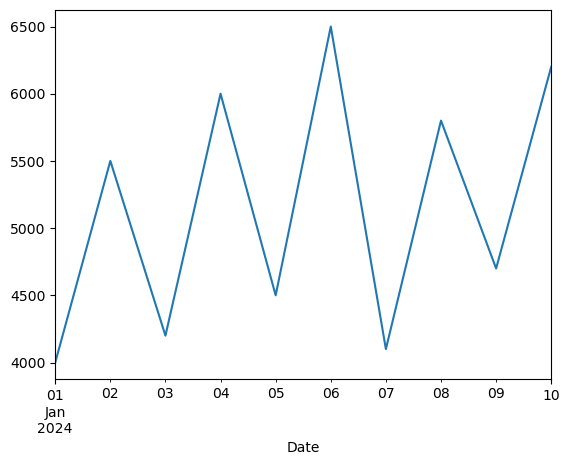

In [143]:
# data visualization
df["Salary"].plot()

<Axes: xlabel='Department'>

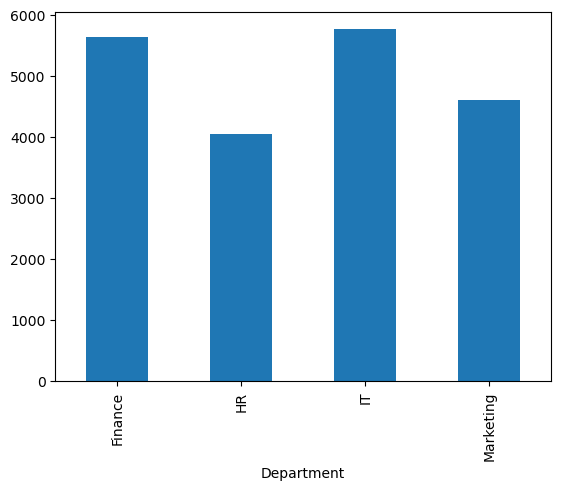

In [144]:
df.groupby("Department")["Salary"].mean().plot(kind="bar")df["Salary"].plot(kind="hist")

<Axes: ylabel='Frequency'>

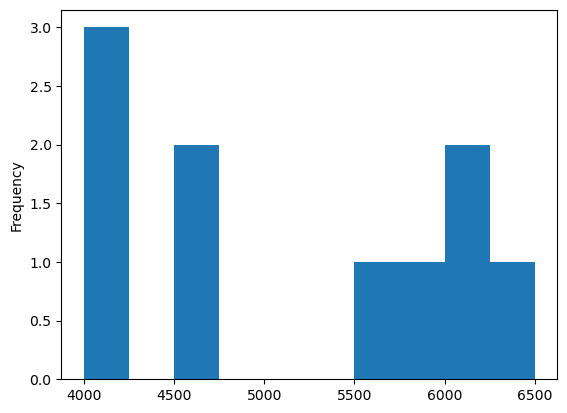

In [145]:
df["Salary"].plot(kind="hist")

In [ ]:
# saving processed data
df.to_csv("output.csv", index=False)
df.to_excel("output.xlsx")